# Lecture 10C.1 — Praat Features with Parselmouth: Pitch, Formants, Jitter, Shimmer


## Goal

Use **Praat-style measurements** in Python via `parselmouth`:

- F0 (pitch track)
- Formants (F1/F2/F3)
- Jitter / Shimmer (voice quality / perturbation)

These features are widely used in speech science, pathology, emotion, and clinical work.


## 1) Setup


In [1]:
import os, json, re, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional audio playback
try:
    from IPython.display import Audio, display
    HAS_IPY_AUDIO = True
except Exception:
    HAS_IPY_AUDIO = False

# ---------------- Project paths (shared manifest workflow) ----------------
PROJECT_ROOT = Path.cwd() / "EE519_L10C_Project"
REC_DIR = PROJECT_ROOT / "recordings"
FIG_DIR = PROJECT_ROOT / "figures"
RES_DIR = PROJECT_ROOT / "results"
FEAT_DIR = PROJECT_ROOT / "features"
MANIFEST_PATH = PROJECT_ROOT / "manifest.json"

for d in [REC_DIR, FIG_DIR, RES_DIR, FEAT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def load_manifest(path=MANIFEST_PATH):
    if path.exists():
        return json.loads(path.read_text())
    return {"course":"EE519","module":"Lecture10C","created_utc":None,"clips":[],"splits":{}}

def save_manifest(manifest, path=MANIFEST_PATH):
    if manifest.get("created_utc") is None:
        manifest["created_utc"] = str(np.datetime64("now"))
    path.write_text(json.dumps(manifest, indent=2))
    print("Saved manifest:", path)

def save_fig(fig, name, dpi=150):
    out = FIG_DIR / name
    fig.savefig(out, dpi=dpi, bbox_inches="tight")
    print("Saved:", out)
    return out

import wave
def read_wav(path: Path):
    with wave.open(str(path), "rb") as wf:
        fs = wf.getframerate()
        n = wf.getnframes()
        x = np.frombuffer(wf.readframes(n), dtype=np.int16).astype(np.float32) / 32768.0
    return fs, x

def peak_normalize(x, target=0.98):
    m = np.max(np.abs(x)) + 1e-12
    return (x / m) * target

def play_audio(x, fs, label="audio"):
    if not HAS_IPY_AUDIO:
        print("(Audio playback not available)", label)
        return
    display(Audio(x, rate=fs))

def list_clips(manifest):
    for i,c in enumerate(manifest.get("clips", [])):
        print(f"[{i}] {c.get('label',''):14s}  {c.get('filename','')}  fs={c.get('fs','?')}  notes={c.get('notes','')}")

def get_segments(clip):
    # We reuse analysis_segments from earlier threads if present
    return clip.get("selections", {}).get("analysis_segments", {})

manifest = load_manifest()
print("Project root:", PROJECT_ROOT)
print("Clips:", len(manifest.get('clips', [])))
list_clips(manifest)


Project root: c:\Users\K\Documents\usc\ee519\ee519-lecture\lecture10c\EE519_L10C_Project
Clips: 12
[0] vowel_a         student10B_vowel_a.wav  fs=16000  notes=steady /a/
[1] vowel_i         student10B_vowel_i.wav  fs=16000  notes=steady /i/
[2] fricative_s     student10B_fricative_s.wav  fs=16000  notes=steady /s/
[3] sentence        student10B_sentence.wav  fs=16000  notes=short sentence
[4] vowel_a         student10B_vowel_a.wav  fs=16000  notes=steady /a/
[5] vowel_i         student10B_vowel_i.wav  fs=16000  notes=steady /i/
[6] fricative_s     student10B_fricative_s.wav  fs=16000  notes=steady /s/
[7] sentence        student10B_sentence.wav  fs=16000  notes=short sentence
[8] vowel_a         student10B_vowel_a.wav  fs=16000  notes=steady /a/
[9] vowel_i         student10B_vowel_i.wav  fs=16000  notes=steady /i/
[10] fricative_s     student10B_fricative_s.wav  fs=16000  notes=steady /s/
[11] sentence        student10B_sentence.wav  fs=16000  notes=short sentence


## 2) Install / import parselmouth (with graceful fallback)

If `parselmouth` is not available:
- you can still follow the conceptual parts,
- and skip extraction cells.


In [2]:
HAS_PM = True
try:
    import parselmouth
    from parselmouth.praat import call
except Exception as e:
    HAS_PM = False
    print("parselmouth not available:", repr(e))
    print("Install: pip install praat-parselmouth")


In [3]:
pip install praat-parselmouth

DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
Note: you may need to restart the kernel to use updated packages.


In [5]:
# /opt/homebrew/opt/python@3.9/bin/python3.9 -m pip install --upgrade pip

## 3) Choose segments to analyze (from manifest)

We will loop over `analysis_segments` in the manifest and compute measurements.


In [3]:
manifest = load_manifest()
rows = []
items = []
for ci, clip in enumerate(manifest.get("clips", [])):
    for seg_name, sel in get_segments(clip).items():
        items.append((ci, seg_name, sel))

print("Segments found:", len(items))
print("Example:", items[0] if items else None)


Segments found: 6
Example: (0, 'vowel_mid', {'t0': 1.0, 't1': 1.5, 's0': 16000, 's1': 24000, 'win_ms': 25.0, 'hop_ms': 10.0, 'N': 400, 'H': 160, 'frame_range': [98, 150]})


## 4) Extract Praat measurements per segment

### What to look for
- Vowels: stable F0, stable formants
- Fricatives: unstable / unvoiced → pitch tracker may return 0 or NaN (expected!)
- Sentences: changing F0 + changing formants over time


In [4]:
def praat_features_for_segment(wav_path, s0, s1):
    fs, x = read_wav(wav_path)
    x = peak_normalize(x)
    xseg = x[int(s0):int(s1)]
    if len(xseg) < int(0.03*fs):
        raise ValueError("Segment too short for stable Praat analysis.")

    snd = parselmouth.Sound(xseg, sampling_frequency=fs)

    # Pitch (F0)
    pitch = snd.to_pitch(time_step=0.01, pitch_floor=75, pitch_ceiling=500)
    f0 = pitch.selected_array['frequency']
    f0 = f0[np.isfinite(f0)]
    f0 = f0[f0 > 0]
    f0_mean = float(np.mean(f0)) if len(f0) else np.nan
    f0_std  = float(np.std(f0)) if len(f0) else np.nan

    # Formants (Burg)
    form = snd.to_formant_burg(time_step=0.01, max_number_of_formants=5,
                               maximum_formant=5500, window_length=0.025, pre_emphasis_from=50.0)
    times = np.arange(0, snd.duration, 0.01)
    def formant_track(i):
        vals = []
        for t in times:
            v = call(form, "Get value at time", i, t, "Hertz", "Linear")
            if v and np.isfinite(v) and v > 0:
                vals.append(v)
        return np.array(vals, dtype=float)
    F1 = formant_track(1); F2 = formant_track(2); F3 = formant_track(3)
    F1m = float(np.mean(F1)) if len(F1) else np.nan
    F2m = float(np.mean(F2)) if len(F2) else np.nan
    F3m = float(np.mean(F3)) if len(F3) else np.nan

    # Jitter / Shimmer (voiced segments only)
    # Praat measures require a PointProcess, which requires voicing
    jitter_local = np.nan
    shimmer_local = np.nan
    try:
        point = call(snd, "To PointProcess (periodic, cc)", 75, 500)
        jitter_local = float(call(point, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3))
        shimmer_local = float(call([snd, point], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6))
    except Exception:
        pass

    return {
        "fs": int(fs),
        "dur_s": float(len(xseg)/fs),
        "f0_mean": f0_mean, "f0_std": f0_std,
        "F1_mean": F1m, "F2_mean": F2m, "F3_mean": F3m,
        "jitter_local": jitter_local,
        "shimmer_local": shimmer_local
    }

if not HAS_PM:
    print("Skipping extraction because parselmouth is missing.")
else:
    feat_rows = []
    for (ci, seg_name, sel) in items:
        clip = manifest["clips"][ci]
        wav_path = REC_DIR / clip["filename"]
        try:
            r = praat_features_for_segment(wav_path, sel["s0"], sel["s1"])
            r.update({"clip_idx":ci, "segment":seg_name, "label":clip.get("label",""), "filename":clip.get("filename","")})
            feat_rows.append(r)
        except Exception as e:
            print("Warn:", (ci,seg_name), repr(e))
    praat_df = pd.DataFrame(feat_rows)
    display(praat_df.head())
    out_csv = FEAT_DIR / "praat_features_segments.csv"
    praat_df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)


,fs,dur_s,f0_mean,f0_std,F1_mean,F2_mean,F3_mean,jitter_local,shimmer_local,clip_idx,segment,label,filename
0,16000,0.5,83.819001,0.720019,669.479025,1398.083520,2048.795365,0.004385,0.070960,0,vowel_mid,vowel_a,student10B_vowel_a.wav
1,16000,0.5,123.633351,2.010204,1369.446762,2589.084350,3680.141358,0.054793,NaN,2,fricative_mid,fricative_s,student10B_fricative_s.wav
2,16000,0.7,98.995476,13.259139,811.115539,2081.933338,3027.912563,0.033313,0.102909,3,seg1,sentence,student10B_sentence.wav
3,16000,0.7,98.995476,13.259139,811.115539,2081.933338,3027.912563,0.033313,0.102909,3,vowel_mid,sentence,student10B_sentence.wav
4,16000,0.5,85.804578,8.310104,766.209288,1729.457216,2647.861497,0.017839,0.090049,3,fricative_mid,sentence,student10B_sentence.wav


Saved: c:\Users\K\Documents\usc\ee519\ee519-lecture\lecture10c\EE519_L10C_Project\features\praat_features_segments.csv


## 5) Visualizations (pick one clip)

We’ll plot:
- waveform segment
- pitch track (if voiced)
- a formant summary (F1/F2/F3 means)


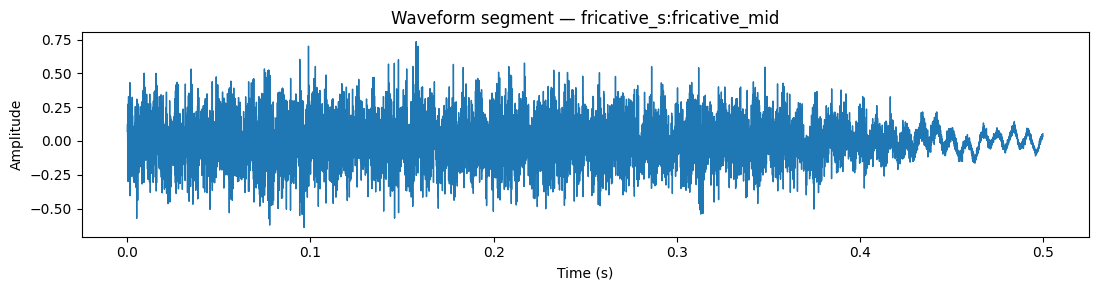

Saved: c:\Users\K\Documents\usc\ee519\ee519-lecture\lecture10c\EE519_L10C_Project\figures\L10C_praat_waveform_c2_fricative_mid.png


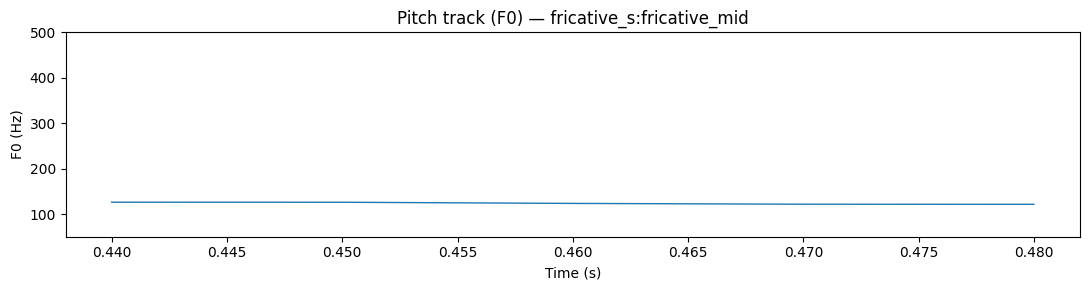

Saved: c:\Users\K\Documents\usc\ee519\ee519-lecture\lecture10c\EE519_L10C_Project\figures\L10C_praat_pitch_c2_fricative_mid.png


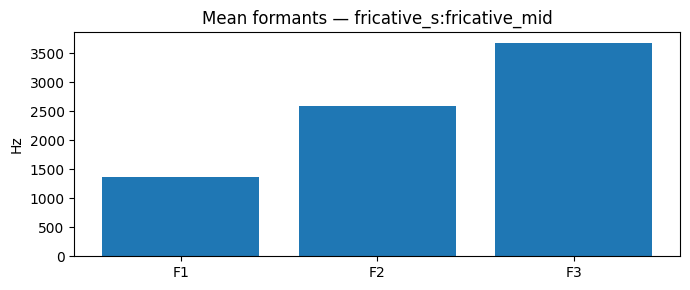

Saved: c:\Users\K\Documents\usc\ee519\ee519-lecture\lecture10c\EE519_L10C_Project\figures\L10C_praat_formants_mean_c2_fricative_mid.png


In [5]:
if HAS_PM and 'praat_df' in globals() and len(praat_df)>0:
    # pick first non-empty voiced segment
    row = praat_df.sort_values("f0_mean", ascending=False).iloc[0]
    ci = int(row["clip_idx"]); seg = row["segment"]
    clip = manifest["clips"][ci]
    sel = get_segments(clip)[seg]
    fs, x = read_wav(REC_DIR/clip["filename"]); x = peak_normalize(x)
    xseg = x[int(sel["s0"]):int(sel["s1"])]
    t = np.arange(len(xseg))/fs

    fig = plt.figure(figsize=(11,3))
    plt.plot(t, xseg, linewidth=1)
    plt.title(f"Waveform segment — {clip.get('label','')}:{seg}")
    plt.xlabel("Time (s)"); plt.ylabel("Amplitude"); plt.tight_layout(); plt.show()
    save_fig(fig, f"L10C_praat_waveform_c{ci}_{seg}.png")

    # Pitch track
    snd = parselmouth.Sound(xseg, sampling_frequency=fs)
    pitch = snd.to_pitch(time_step=0.01, pitch_floor=75, pitch_ceiling=500)
    pitch_values = pitch.selected_array['frequency']
    pitch_times = pitch.xs()
    pitch_values = np.where(pitch_values>0, pitch_values, np.nan)

    fig = plt.figure(figsize=(11,3))
    plt.plot(pitch_times, pitch_values, linewidth=1)
    plt.title(f"Pitch track (F0) — {clip.get('label','')}:{seg}")
    plt.xlabel("Time (s)"); plt.ylabel("F0 (Hz)"); plt.ylim(50, 500)
    plt.tight_layout(); plt.show()
    save_fig(fig, f"L10C_praat_pitch_c{ci}_{seg}.png")

    # Formant summary bar
    fig = plt.figure(figsize=(7,3))
    plt.bar(["F1","F2","F3"], [row["F1_mean"], row["F2_mean"], row["F3_mean"]])
    plt.title(f"Mean formants — {clip.get('label','')}:{seg}")
    plt.ylabel("Hz"); plt.tight_layout(); plt.show()
    save_fig(fig, f"L10C_praat_formants_mean_c{ci}_{seg}.png")


## Reflection questions

1) For an **unvoiced fricative**, what does Praat return for F0 and why is that not an error?  
2) What do F1/F2 roughly correspond to in articulation terms (tongue height / frontness)?  
3) When would jitter/shimmer be meaningful, and when would they be misleading?


### Answers

1. It didn't return anything and that isn't an error because unvoiced fricatives don't have fundamental frequency.
2. F1 corresponds to tongue height and F2 corresponds to tongue frontness.
3. Jitter/shimmer and meaningful sustained voices but not for noisy or unvoiced clips.

## What’s next
- **10C.2** openSMILE: a standardized feature set used widely in emotion + health.
